# Node folder QC: script, geophone pulse test, orientation, response

Besides `DigiSolo.LOG`, each SmartSolo node leaves a handful of small files. This notebook reads them with `lib/smartsolo_node.py` and shows what they tell us about the sensor: test limits, the geophone pulse test (natural frequency, damping, noise floor), boot-by-boot QC, orientation and an instrument response.

In [1]:
import sys; sys.path.insert(0, "../lib")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore", message="obj.round")
import smartsolo_log as sl, smartsolo_locate as loc, smartsolo_node as sn, smartsolo_waveforms as wf
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
NODE = Path("../data/nodes/453022522")

## 1. What is in a node folder

In [2]:
pd.DataFrame([(p.name, p.stat().st_size) for p in sorted(NODE.iterdir())], columns=["file", "bytes"])

,file,bytes
0,DigiSolo.LOG,2073147
1,DigiSolo.TXT,36
2,PULSE_X.WAV,48044
3,PULSE_Y.WAV,48044
4,PULSE_Z.WAV,48044
5,SCT_INT.XML,1063
6,device.ini,56
7,guardfile.db,5120
8,sct_par.xml,1955
9,sct_par_b.xml,1955


| file | content |
|---|---|
| `device.ini` | serial number and firmware |
| `sct_par.xml`, `sct_par_b.xml` | acquisition script (the `_b` file is an identical backup) |
| `SCT_INT.XML` | script as interpreted by the node (adds channel 4) |
| `DigiSolo.LOG` | state-of-health log |
| `PULSE_X/Y/Z.WAV` | geophone pulse test of the **latest** power-up, one file per axis |
| `DigiSolo.TXT` | file-system marker |
| `guardfile.db` | binary journal of recent log keys, nothing new |

In [3]:
node = sn.read_node_folder(NODE)
print("serial:", node["serial"], " firmware:", node["firmware"], " backup script identical:", node["script_backup_identical"])
node["limits"]

serial: 453022522  firmware: V1.0.8.1be  backup script identical: True


{'resistance_ohm': (1640, 1905),
 'damping': (0.647, 0.752),
 'resonate_freq_hz': (4.63, 5.37),
 'sensitivity_v_per_m_s': (71, 82),
 'battery_threshold_v': 6.5,
 'battery_critical_v': 6.0,
 'battery_full_v': 8.35,
 'gps_relock_warning_s': 7200,
 'sample_rate_hz': 100,
 'gains_db': [0, 0, 0]}

The script sets the acceptance limits for the boot-time geophone test (resistance 1640–1905 Ω, damping 0.647–0.752, natural frequency 4.63–5.37 Hz, sensitivity 71–82 V/m/s), battery thresholds (6.5 V low, 6.0 V critical, 8.35 V full), 100 sps, 0 dB gain. Also note `MiniSeed_Output_Mode = 0`: the node stores **DLD** files (`Seis000.DLD` … in the log's Notify records), which must be exported with SoloLite before ObsPy can read them.

In [4]:
node["script"]

prospect                                         DML
script_file_name                  dmlparameterscript
project_name                                     DML
device_type                          IGU-16HR 3C 5Hz
ChNumber                                           3
DeviceRunMode                                      0
begin_Day                                 2024/11/13
begin_time                                  00,00,00
end_time                                    00,00,00
GPS_Mode                                           1
Sample_Rate                                      100
Flash_FIFO_MODE                                    1
MiniSeed_Output_Mode                               0
Auxiliary_Address                                  1
LED_Trouble_Shooting                              30
Channel_1_type                                    98
Channel_1_Gain                                     0
Channel_2_type                                    98
Channel_2_Gain                                

## 2. The pulse test

The WAV header says 10 000 Hz, but the file holds the 16-second geophone/ADC test stage (SmartSolo hardware manual) in 16 000 samples, i.e. **1000 sps**. At the header rate the geophone would ring at ~50 Hz, impossible for a 5 Hz DT-SOLO; at 1000 sps it gives ~4.95 Hz and h ≈ 0.71, as in the log. `read_pulse` therefore uses 1000 Hz by default.

10000 Hz in WAV header -> 1000.0 Hz used


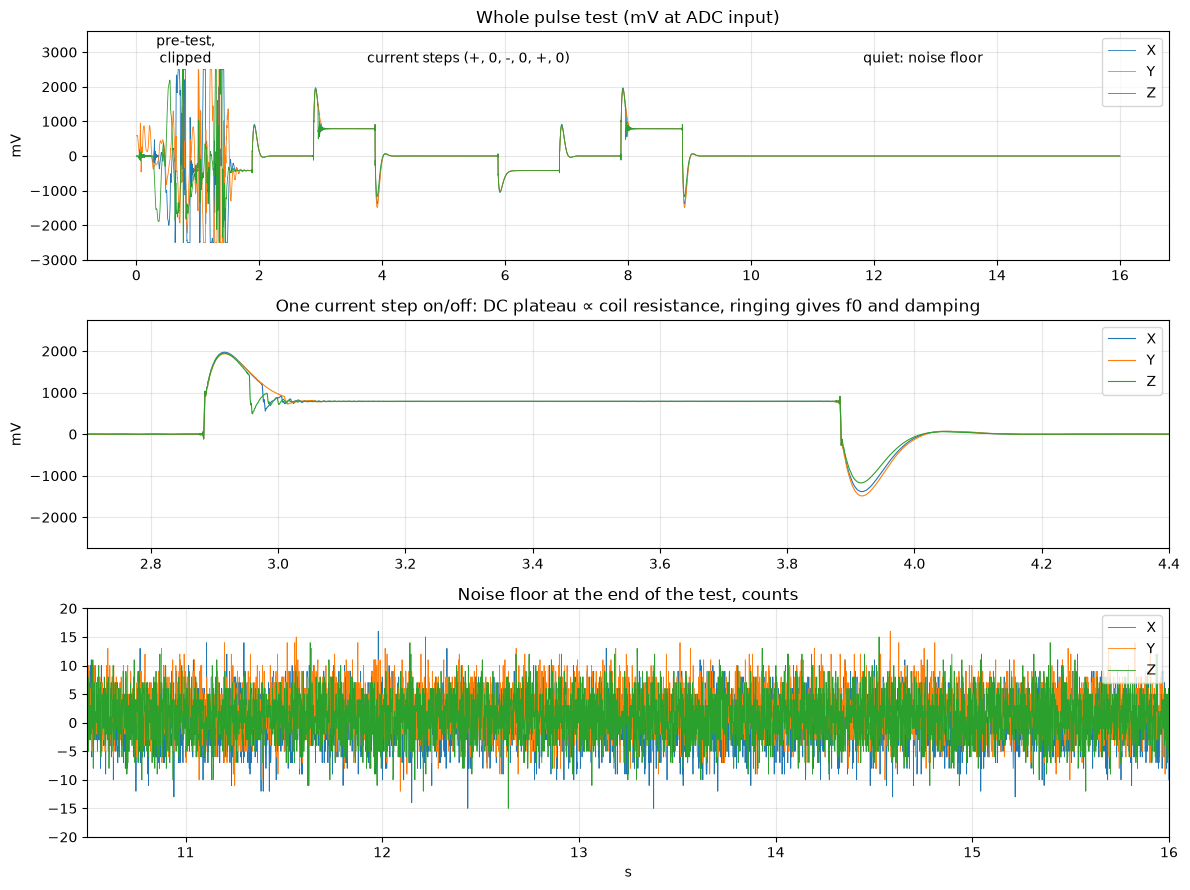

In [5]:
tr = {ax: sn.read_pulse(NODE / f"PULSE_{ax}.WAV") for ax in "XYZ"}
print(tr["Z"].stats.wav_header_rate, "Hz in WAV header ->", tr["Z"].stats.sampling_rate, "Hz used")

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for ax_name, t in tr.items():
    x = t.times(); y = t.data / sn.counts_per_volt(0) * 1e3      # mV
    axes[0].plot(x, y, lw=.6, label=ax_name)
    axes[1].plot(x, y, lw=.8, label=ax_name)
    axes[2].plot(x, t.data, lw=.6, label=ax_name)
axes[0].set(title="Whole pulse test (mV at ADC input)", ylabel="mV")
axes[0].set_ylim(-3000, 3600)
for a, txt in [(0.8, "pre-test,\nclipped"), (5.4, "current steps (+, 0, -, 0, +, 0)"), (12.8, "quiet: noise floor")]:
    axes[0].annotate(txt, (a, 2700), ha="center")
axes[1].set(xlim=(2.7, 4.4), title="One current step on/off: DC plateau ∝ coil resistance, ringing gives f0 and damping", ylabel="mV")
axes[2].set(xlim=(10.5, 16), ylim=(-20, 20), title="Noise floor at the end of the test, counts", xlabel="s")
for a in axes: a.legend(loc="upper right"); a.grid(alpha=.3)
plt.tight_layout()

Fit of a damped oscillation after each step:

In [6]:
res = sn.analyse_pulse(tr["X"])
res["steps"][["time_s", "kind", "polarity", "level_after_mV", "f0_hz", "damping", "rel_residual"]].round(3)

,time_s,kind,polarity,level_after_mV,f0_hz,damping,rel_residual
0,1.883,off,-1.0,-0.073,4.945,0.711,0.002
1,2.882,on,1.0,788.544,5.693,0.691,0.031
2,3.882,off,1.0,-0.205,5.353,0.696,0.005
3,5.883,on,-1.0,-421.143,4.860,0.999,0.003
4,6.883,off,-1.0,-0.181,4.947,0.711,0.002
5,7.882,on,1.0,788.464,5.684,0.691,0.031
6,8.882,off,1.0,0.213,5.345,0.695,0.006


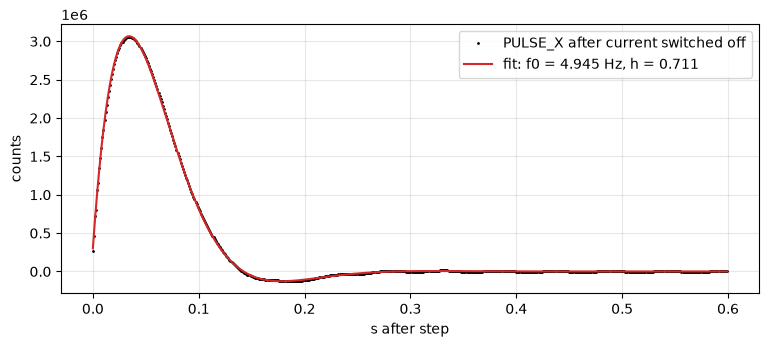

In [7]:
from smartsolo_node import _damped
st = res["steps"]; e = st[(st.kind == "off") & (st.polarity < 0)].iloc[0]
t = tr["X"]; i = int(e.time_s * t.stats.sampling_rate) + 3
seg = t.data[i:i + 600].astype(float); tt = np.arange(len(seg)) / t.stats.sampling_rate
from scipy.optimize import curve_fit
p, _ = curve_fit(_damped, tt, seg, p0=[seg[np.argmax(abs(seg))], 5, .7, 0, 0])
plt.figure(figsize=(9, 3.5))
plt.plot(tt, seg, "k.", ms=2, label="PULSE_X after current switched off")
plt.plot(tt, _damped(tt, *p), "C3", label=f"fit: f0 = {p[1]:.3f} Hz, h = {p[2]:.3f}")
plt.xlabel("s after step"); plt.ylabel("counts"); plt.legend(); plt.grid(alpha=.3);

Summary per axis, compared with the last boot-time test in the log (boot 4, after recovery). The noise floor of ~3.9 counts = **1.16 µV** reproduces the log's `ChN RMS Noise` (so that field is in µV), and f0/damping agree within ~2 %. The steps switched off from the positive current give a slightly higher f0 (~5.35 Hz) – the larger positive drive moves the mass further, so this is likely suspension non-linearity; the negative-step values are used as the summary.

In [8]:
pulse = node["pulse"].drop(columns="file")
last = node["qc"][node["qc"].boot_no == node["qc"].boot_no.max()]
cmp_ = pd.concat([pulse[["axis", "f0_hz", "damping", "noise_rms_uV"]].reset_index(drop=True),
                  last[["channel", "resonate_freq_hz", "damping", "rms_noise_uV"]].reset_index(drop=True)
                      .add_prefix("log_")], axis=1)
cmp_.round(3)

,axis,f0_hz,damping,noise_rms_uV,log_channel,log_resonate_freq_hz,log_damping,log_rms_noise_uV
0,X,4.946,0.711,1.163,1,4.915,0.714,1.157
1,Y,4.975,0.709,1.144,2,4.961,0.711,1.153
2,Z,4.976,0.724,1.156,3,4.865,0.698,1.135


The log's Ch1/Ch2/Ch3 can't be matched to X/Y/Z from these numbers alone – the differences are as large as the differences between the two methods. SmartSolo's manual defines **X = north–south (positive = case moving south), Y = east–west (positive = case moving west), Z = vertical (positive = case moving down)**, i.e. SEG geophone polarity. EarthScope reported that archived SmartSolo Z data did *not* follow the down-positive convention, so check polarity on real data (e.g. a hammer shot or a teleseism) before trusting either.

## 3. Boot-by-boot geophone QC

In [9]:
qc = pd.concat([sn.geophone_qc(sl.read_device_info(f)) for f in loc.find_logs("../data/nodes")])
cols = ["serial", "boot_no", "boot_time", "channel", "resistance_1_ohm", "coil_temp_est_c", "resonate_freq_hz",
        "damping", "sensitivity", "spread_noise", "logged_test_passed", "ok_all", "noisy"]
qc[cols].round(2)

,serial,boot_no,boot_time,channel,resistance_1_ohm,coil_temp_est_c,resonate_freq_hz,damping,sensitivity,spread_noise,logged_test_passed,ok_all,noisy
0,453021267,1,2024-11-13 04:35:04+00:00,1,1761.9,12.88,5.01,0.72,77.41,34553.62,NaN,True,True
1,453021267,1,2024-11-13 04:35:04+00:00,2,1750.4,11.30,0.00,0.00,0.00,47799.33,NaN,False,True
2,453021267,1,2024-11-13 04:35:04+00:00,3,1758.2,12.37,4.56,0.72,73.91,72142.21,NaN,False,True
3,453021267,2,2024-12-24 13:10:50+00:00,1,1633.0,-4.85,3.94,0.53,62.28,7318.01,NaN,False,True
4,453021267,2,2024-12-24 13:10:50+00:00,2,1643.5,-3.40,3.62,0.33,59.83,42941.22,NaN,False,True
5,453021267,2,2024-12-24 13:10:50+00:00,3,1667.5,-0.10,4.92,0.38,51.89,18873.23,NaN,False,True
6,453021267,3,2024-12-25 14:17:18+00:00,1,1606.5,-8.49,0.00,0.00,0.00,64043.39,0.0,False,True
7,453021267,3,2024-12-25 14:17:18+00:00,2,1621.4,-6.44,123.97,0.09,453.53,1503.33,0.0,False,False
8,453021267,3,2024-12-25 14:17:18+00:00,3,1611.9,-7.75,0.00,0.00,0.00,488.42,0.0,False,False
9,453021267,4,2024-12-25 14:25:51+00:00,1,1608.1,-8.27,5.03,0.75,78.15,12.52,1.0,True,False


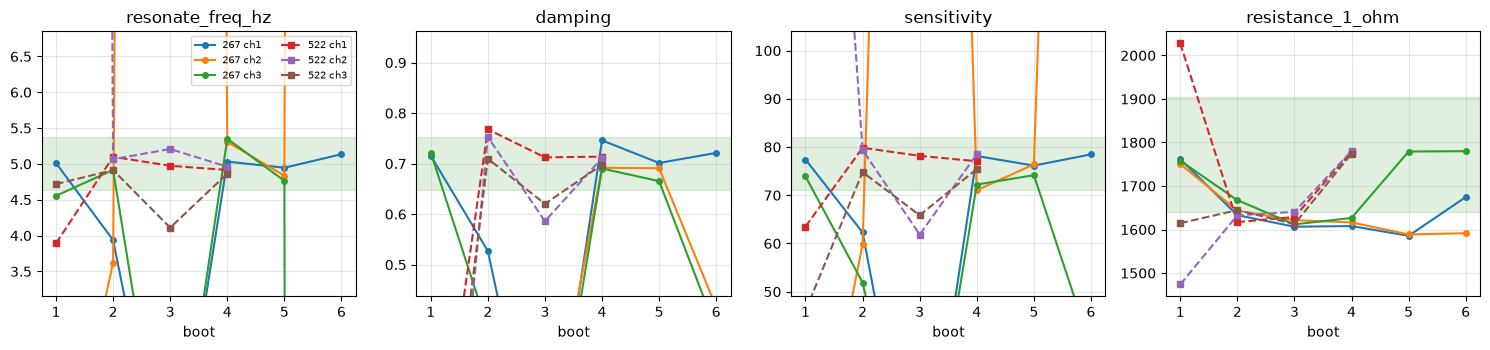

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True)
lim = node["limits"]
for a, (col, key) in zip(axes, [("resonate_freq_hz", "resonate_freq_hz"), ("damping", "damping"),
                               ("sensitivity", "sensitivity_v_per_m_s"), ("resistance_1_ohm", None)]):
    for (serial, ch), g in qc.groupby(["serial", "channel"]):
        a.plot(g.boot_no, g[col], "o-" if serial.endswith("267") else "s--", label=f"{serial[-3:]} ch{ch}", ms=4)
    if key:
        a.axhspan(*lim[key], color="g", alpha=.12)
        lo, hi = lim[key]; a.set_ylim(lo - 2 * (hi - lo), hi + 2 * (hi - lo))
    a.set(title=col, xlabel="boot")
    a.grid(alpha=.3)
axes[-1].axhspan(1640, 1905, color="g", alpha=.12)
axes[0].legend(fontsize=7, ncol=2); plt.tight_layout()

What this shows:

- **Deployment boots** (453021267 boot 4, 453022522 boot 3) were tested at −2 to −4 °C. The coil resistance tracks temperature like copper: ~1610–1630 Ω cold vs ~1780 Ω after recovery – a ~9 % drop, i.e. about 25 °C colder (`coil_temp_est_c`, assuming 1850 Ω at 25 °C). The script compares against temperature-corrected limits (the second number in `Lower/Upper Resistance Limit`), so cold coils still pass.
- 453022522 boot 3 has **high spread noise** (6 900–22 400) – the node was probably still being handled or settling while it tested itself – and Ch2/Ch3 damping and sensitivity are outside the limits, yet `Geophone Test Passed = 1`. Its tests at recovery (boot 4) are all within limits, so the sensor itself is fine; the deployment-time values just aren't reliable.
- 453021267 boot 4 is a clean test (spread noise 12–44) and passes.
- Bench/transport boots (1, 2, 5, 6) include impossible values (f0 = 0, 134 Hz, −385 Hz, negative damping) – tests while the node was lying on its side or moving. Use `noisy`, `ok_all` and the boot reason, not just the logged pass flag.

## 4. Orientation

In [11]:
deps = loc.build_deployments("../data/nodes")
orient = deps[["deployment_id", "ecompass_north_median", "ecompass_north_std", "tilted_angle_median",
               "roll_angle_median", "pitch_angle_median", "latitude", "longitude", "start"]].copy()
orient["declination"] = [sn.magnetic_declination(r.latitude, r.longitude, r.start, 1650) for r in orient.itertuples()]
orient.round(2)

,deployment_id,ecompass_north_median,ecompass_north_std,tilted_angle_median,roll_angle_median,pitch_angle_median,latitude,longitude,start,declination
0,453021267_004,156.80,0.92,1.67,1.66,0.12,-71.55,11.12,2024-12-25 14:26:27+00:00,-29.48
1,453022522_003,126.42,0.88,5.13,2.86,4.25,-71.55,11.12,2024-12-25 15:20:06+00:00,-29.49


- **Tilt**: 453021267 sits at 1.7°, 453022522 at **5.1°**. The data sheet gives distortion specs for horizontal geophones at 0–3° tilt, so 453022522's horizontals are outside that range; the vertical spec (0–10°) is still met.
- **eCompass**: 157° and 126°, each stable to ~1° over two weeks. IGRF declination here is about −29.5°. If `eCompass North` is the magnetic azimuth of the node's N arrow, the arrows were pointing about 127° and 97° (true), not north – and differently for the two nodes. Either the nodes weren't aligned to north, or the compass wasn't calibrated (the script's eCompass calibration mode). This needs checking against field notes before rotating horizontals; the StationXML still uses N = 0°, E = 90°.

## 5. Instrument response

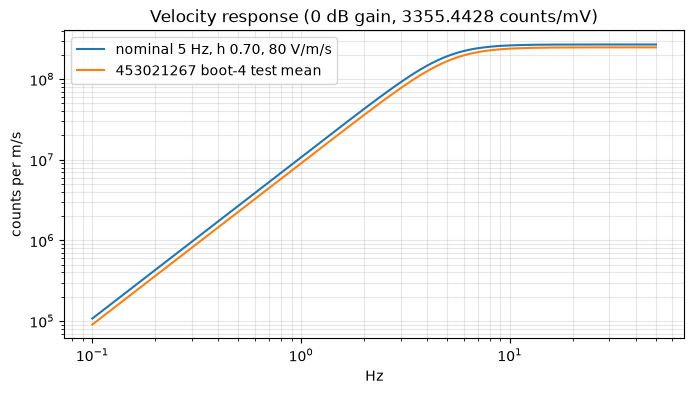

In [12]:
nom = sn.geophone_response(**{k: sn.NOMINAL_5HZ[k] for k in ["f0", "damping", "sensitivity"]})
d = deps.set_index("deployment_id").loc["453021267_004"]
test = sn.geophone_response(d.test_resonate_freq_hz_mean, d.test_damping_mean, d.test_sensitivity_mean)
f = np.logspace(-1, 1.7, 300)
fig, ax = plt.subplots(figsize=(8, 4))
for r, lab in [(nom, "nominal 5 Hz, h 0.70, 80 V/m/s"), (test, "453021267 boot-4 test mean")]:
    h = r.get_evalresp_response_for_frequencies(f, output="VEL")
    ax.loglog(f, np.abs(h), label=lab)
ax.set(xlabel="Hz", ylabel="counts per m/s", title="Velocity response (0 dB gain, 3355.4428 counts/mV)")
ax.grid(alpha=.3, which="both"); ax.legend();

In [13]:
inv = wf.build_inventory(deps, mapping="../data/station_mapping.csv", response="test")
for net in inv:
    for sta in net:
        print(sta.code, sta.channels[0].response.instrument_sensitivity.value,
              "counts/(m/s) at", sta.channels[0].response.instrument_sensitivity.frequency, "Hz")

GL01 245625410.307315 counts/(m/s) at 15.0 Hz
GL02 267381181.63914096 counts/(m/s) at 15.0 Hz


`response="test"` uses each deployment's own boot test if it passed and was not noisy; otherwise (here 453022522) it falls back to the nominal values. The anti-alias FIR filter is not included.